Import bibliotek:

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.preprocessing import LabelEncoder
sns.set_theme()

Wczytanie pliku:

In [69]:
df = pd.read_csv('star_classification.csv')
df.head(10)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
5,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,QSO,1.424659,5026,55855,741
6,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,QSO,0.586455,11069,58456,113
7,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,GALAXY,0.477009,6183,56210,15
8,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,GALAXY,0.660012,6625,56386,719
9,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,STAR,-0.000008,2444,54082,232


Usunięcie kolumn zawierjących dane porządkowe:

In [70]:
df.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='str')

In [71]:
df = df.drop(columns=['obj_ID','run_ID','rerun_ID','cam_col','field_ID','spec_obj_ID','plate','MJD','fiber_ID'])

In [72]:
df

,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123
...,...,...,...,...,...,...,...,...,...
99995,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,GALAXY,0.000000
99996,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,GALAXY,0.404895
99997,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,GALAXY,0.143366
99998,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,GALAXY,0.455040


Sprawdzenie, czy występują wiersze bez wartości:

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   alpha     100000 non-null  float64
 1   delta     100000 non-null  float64
 2   u         100000 non-null  float64
 3   g         100000 non-null  float64
 4   r         100000 non-null  float64
 5   i         100000 non-null  float64
 6   z         100000 non-null  float64
 7   class     100000 non-null  str    
 8   redshift  100000 non-null  float64
dtypes: float64(8), str(1)
memory usage: 6.9 MB


In [74]:
df.dropna(inplace= True)

Sprawdzenie czy są duplikaty

In [75]:
print(df.duplicated().sum())

0


Sprawdzenie ilości obiektów w bazie:

In [76]:
df['class'].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

<Axes: xlabel='class', ylabel='Count'>

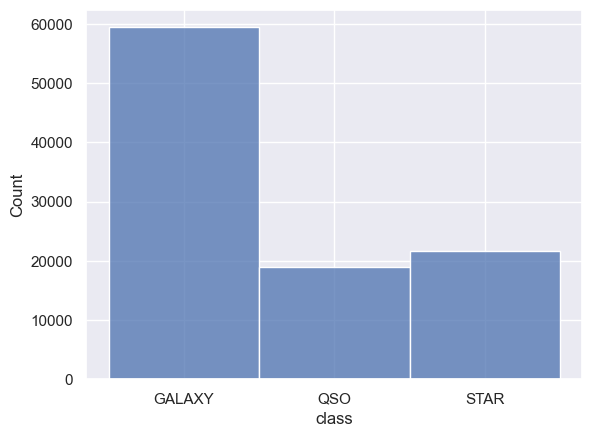

In [77]:
sns.histplot(df['class'], bins=20)

Zmniejszenie ilości typu - GALAXY:

<Axes: >

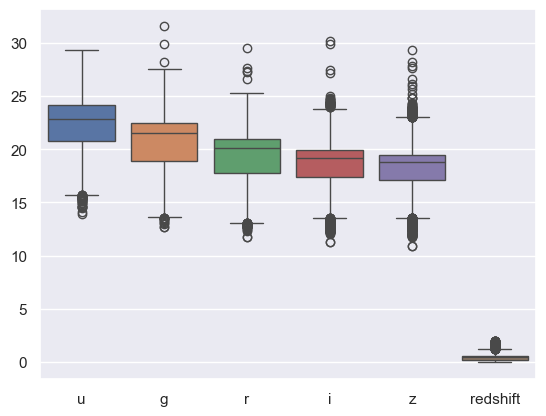

In [78]:
kolumny = [ 'u', 'g', 'r', 'i', 'z', 'redshift']
sns.boxplot(data=df[df['class'] == 'GALAXY'][kolumny])

Usunięcie kilku rekordów z najpowszechniejszymi danymi:

In [79]:
galaxies = df[df['class'] == 'GALAXY']

In [80]:
galaxies

,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123
...,...,...,...,...,...,...,...,...,...
99995,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,GALAXY,0.000000
99996,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,GALAXY,0.404895
99997,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,GALAXY,0.143366
99998,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,GALAXY,0.455040


In [99]:

mean_val = galaxies[kolumny].mean()
galaxies['distance_from_mean'] = abs(galaxies[kolumny] - mean_val).sum(axis=1)
galaxies_to_keep = galaxies.sort_values('distance_from_mean').iloc[16000:]

lub losowe usuniecie

In [ ]:
#galaxies_to_keep = galaxies.sample(n=45000, random_state=69)

In [83]:
galaxies_to_keep

,alpha,delta,u,g,r,i,z,class,redshift
65821,220.245289,43.197586,21.23310,19.70493,18.05526,17.42388,17.04642,GALAXY,0.317235
51223,324.244560,0.139633,18.34602,16.40873,15.50453,15.08135,14.73549,GALAXY,0.056868
10147,329.582593,6.256710,23.51731,21.11691,19.22181,18.62060,18.24203,GALAXY,0.337357
73786,182.460437,36.629752,21.27913,18.98855,18.09158,17.67779,17.34555,GALAXY,0.137749
48965,130.079615,55.292147,23.12588,22.24564,20.49050,19.60152,19.08041,GALAXY,0.536173
...,...,...,...,...,...,...,...,...,...
91708,328.683296,30.496682,22.59117,23.95787,21.13717,19.90550,19.25789,GALAXY,0.618840
448,7.759490,11.959672,21.78860,19.63243,18.14623,17.57222,17.14286,GALAXY,0.256000
25617,2.830327,-9.685460,21.51603,20.48537,19.89449,19.51402,19.21734,GALAXY,0.773470
66781,2.989054,27.517490,21.00631,21.06781,20.17984,19.47032,19.28153,GALAXY,0.552098


Wymiana na nowy zbiór galaktyk:

In [84]:
do_usuniecia = df[df['class'] == 'GALAXY'].index
df = df.drop(do_usuniecia)

In [85]:
df2 = pd.concat([galaxies_to_keep, df])

In [86]:
#df2 = df2.drop('distance_from_mean', axis=1)

<Axes: >

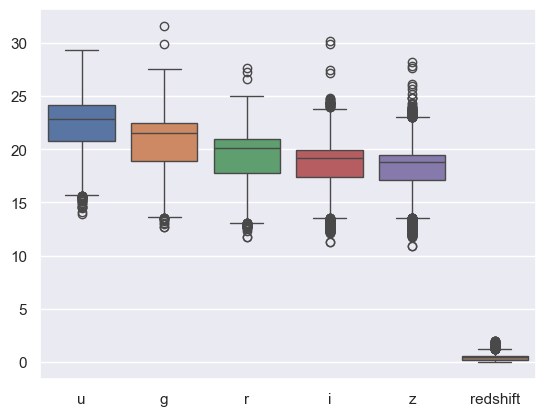

In [100]:
sns.boxplot(data=df2[df2['class'] == 'GALAXY'][kolumny])

<Axes: xlabel='class', ylabel='Count'>

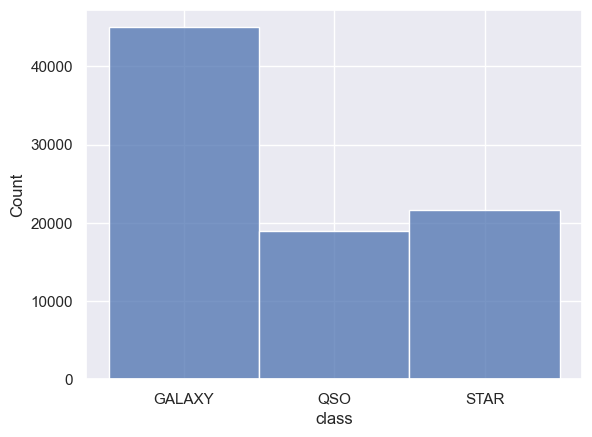

In [87]:
sns.histplot(df2['class'], bins=20)

Sprawdzenie poprawności rekordów typu STAR

<Axes: >

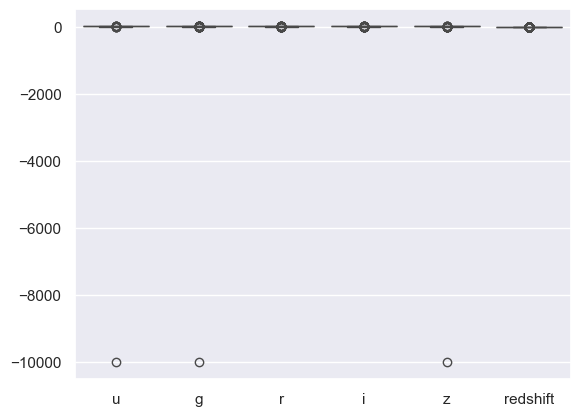

In [88]:
sns.boxplot(data=df2[df2['class'] == 'STAR'][kolumny])

"Ukryte" braki danych

In [89]:
df2.replace(-9999, np.nan, inplace=True)
df2.dropna(inplace=True)


<Axes: >

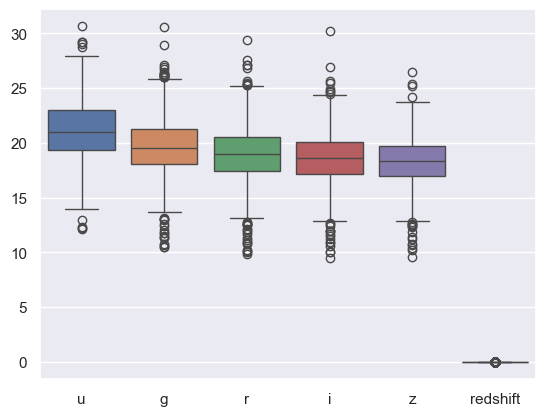

In [90]:
sns.boxplot(data=df2[df2['class'] == 'STAR'][kolumny])

Sprawdzenie wartości obiektów QSO

<Axes: >

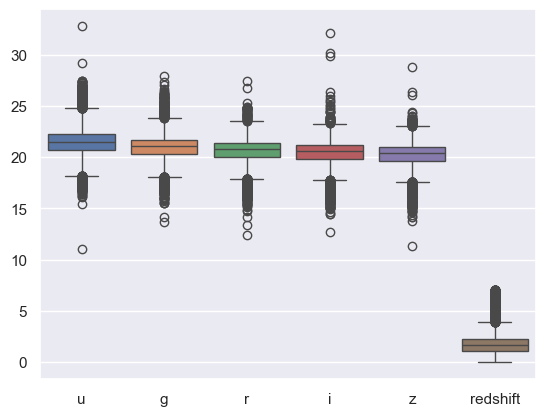

In [91]:
sns.boxplot(data=df2[df2['class'] == 'QSO'][kolumny])

One-Hot-Encoding

In [92]:
#df_encoded = pd.get_dummies(df2, columns=['class'])

lub label encoding

In [93]:
le = LabelEncoder()
df_encoded = df2
df_encoded['target'] = le.fit_transform(df2['class']) 
df_encoded =df_encoded.drop('class',axis = 1)

In [94]:
df_encoded.tail(8)

,alpha,delta,u,g,r,i,z,redshift,target
99953,178.261225,1.174416,21.18402,20.72292,20.75580,20.48850,20.46614,0.576586,1
99955,172.281648,-8.909060,22.26657,20.76710,20.22759,20.08172,19.98396,-0.000395,2
99959,169.371328,12.285850,22.28911,21.02551,20.72092,20.54853,20.10718,0.000367,2
99961,134.347759,47.771911,24.17897,22.89025,21.26451,20.94941,19.87500,0.219966,1
99966,222.761686,32.203212,20.23421,19.76480,19.46940,19.36135,19.21768,0.398574,1
99968,259.504325,31.462416,24.86685,23.22772,21.82982,21.80359,21.56733,1.239638,1
99977,217.958430,52.316738,24.15617,22.05986,21.80826,21.95129,21.24179,1.067543,1
99980,225.566376,32.118746,20.53765,19.93229,19.77495,19.72304,19.40202,2.488738,1


Ostateczne sprawdzenie, czy zbiór jest gotowy:

In [95]:
df_encoded.isnull().sum()

alpha       0
delta       0
u           0
g           0
r           0
i           0
z           0
redshift    0
target      0
dtype: int64

In [96]:
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 85554 entries, 65821 to 99980
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   alpha     85554 non-null  float64
 1   delta     85554 non-null  float64
 2   u         85554 non-null  float64
 3   g         85554 non-null  float64
 4   r         85554 non-null  float64
 5   i         85554 non-null  float64
 6   z         85554 non-null  float64
 7   redshift  85554 non-null  float64
 8   target    85554 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 6.5 MB


Sprawdzenie, czy kolumny nie mają za dużej korelacji:

In [97]:
df_encoded.corr()

,alpha,delta,u,g,r,i,z,redshift,target
alpha,1.000000,0.138847,0.002975,-0.008844,-0.013656,-0.013732,-0.014398,0.005057,-0.014322
delta,0.138847,1.000000,-0.031055,-0.007664,-0.003561,0.000757,0.000580,0.034145,0.011407
u,0.002975,-0.031055,1.000000,0.855606,0.727033,0.611410,0.536860,0.154147,-0.278636
g,-0.008844,-0.007664,0.855606,1.000000,0.931536,0.841865,0.768674,0.307802,-0.242448
r,-0.013656,-0.003561,0.727033,0.931536,1.000000,0.961048,0.916464,0.425354,-0.090441
i,-0.013732,0.000757,0.611410,0.841865,0.961048,1.000000,0.970865,0.487154,-0.000554
z,-0.014398,0.000580,0.536860,0.768674,0.916464,0.970865,1.000000,0.497018,0.050903
redshift,0.005057,0.034145,0.154147,0.307802,0.425354,0.487154,0.497018,1.000000,-0.086366
target,-0.014322,0.011407,-0.278636,-0.242448,-0.090441,-0.000554,0.050903,-0.086366,1.000000


In [98]:
df_encoded.describe()

,alpha,delta,u,g,r,i,z,redshift,target
count,85554.000000,85554.000000,85554.000000,85554.000000,85554.000000,85554.000000,85554.000000,85554.000000,85554.000000
mean,177.737622,24.249617,21.994345,20.582645,19.652000,19.120738,18.819358,0.602300,0.726407
std,96.812443,19.710171,2.239045,2.022220,1.851192,1.766793,1.778303,0.779237,0.838766
min,0.005528,-18.785328,10.996230,10.498200,9.822070,9.469903,9.612333,-0.009971,0.000000
25%,126.936136,5.148196,20.303807,18.970022,18.189600,17.795803,17.531318,0.000682,0.000000
50%,181.082717,23.934543,22.060490,21.022960,20.125785,19.437875,19.047505,0.411495,0.000000
75%,234.537184,40.185048,23.583987,22.059535,21.049307,20.459447,20.002985,0.748587,2.000000
max,359.999810,83.000519,32.781390,31.602240,29.374110,32.141470,28.790550,7.011245,2.000000
